<center>
<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
            padding: 12px 40px;
            border-radius: 8px;
            border-left: 4px solid #00d4ff;
            box-shadow: 0 4px 20px rgba(0, 212, 255, 0.15);
            margin: 15px 0;
            width: 100%;
            box-sizing: border-box;">
    <h1 style="color: #00d4ff; 
               font-family: 'Consolas', 'Courier New', monospace; 
               font-size: 28px; 
               font-weight: 700; 
               margin: 0;
               letter-spacing: 1px;
               text-shadow: 0 0 20px rgba(0, 212, 255, 0.3);
               text-align: center;">
        🎯 DATA_GENERATION
    </h1>
    <p style="color: rgba(255,255,255,0.6); 
              font-size: 13px; 
              margin: 4px 0 0 0;
              font-family: 'Consolas', 'Courier New', monospace;
              letter-spacing: 0.5px;
              text-align: center;">
        synthetic_data · visualization · geometry
    </p>
</div>
</center>

<center>
<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
            padding: 12px 40px;
            border-radius: 8px;
            border-left: 4px solid #00d4ff;
            box-shadow: 0 4px 20px rgba(0, 212, 255, 0.15);
            margin: 15px 0;
            width: 100%;
            box-sizing: border-box;">
    <h1 style="color: #00d4ff; 
               font-family: 'Consolas', 'Courier New', monospace; 
               font-size: 28px; 
               font-weight: 700; 
               margin: 0;
               letter-spacing: 1px;
               text-shadow: 0 0 20px rgba(0, 212, 255, 0.3);
               text-align: center;">
        📊 Глава 1: DATA_GENERATION & VISUALIZATION
    </h1>
    <p style="color: rgba(255,255,255,0.6); 
              font-size: 13px; 
              margin: 4px 0 0 0;
              font-family: 'Consolas', 'Courier New', monospace;
              letter-spacing: 0.5px;
              text-align: center;">
        synthetic_data · multivariate_normal · geometry · decision_boundary
    </p>
</div>
</center>

## 📐 1. Многомерное нормальное распределение

### Что это и зачем нам?

Для генерации синтетических данных для SVM нам нужно создавать **облака точек** — классы, которые мы будем разделять. Самое естественное и контролируемое распределение для этого — **многомерное нормальное (гауссовское)** распределение.

В двумерном случае (наши графики — это оси X и Y) распределение задаётся:

- **Вектором среднего** μ = (μx, μy) — центр облака
- **Ковариационной матрицей** Σ = [[σx², σxy], [σxy, σy²]]

### Как форма облака зависит от ковариационной матрицы

| Что хотим получить | Ковариационная матрица Σ |
|---|---|
| Круг | σx² = σy², σxy = 0 |
| Овал по горизонтали | σx² > σy², σxy = 0 |
| Овал по вертикали | σy² > σx², σxy = 0 |
| Наклонный овал | σxy ≠ 0 |

### Связь с линиями уровня (повторение геометрии)

Контуры плотности нормального распределения — это **эллипсы**. Их оси — это собственные векторы Σ, а длины полуосей пропорциональны √(собственным значениям). Это ровно та же геометрическая картина, что и линии уровня функции — только теперь мы применяем её к распределению данных.

### Практический смысл

Мы можем **полностью контролировать**:
- **Положение** класса на плоскости (через μ)
- **Форму** класса (через Σ)
- **Размер** класса (через σx², σy²)
- **Наклон** класса (через σxy)

Это даёт нам возможность создавать любые конфигурации данных для тестирования SVM.

## 🎯 2. Генерация данных для линейного SVM

### Теория

Для демонстрации работы **линейного SVM** (Primal, градиентный спуск) нам нужны два класса, которые **можно разделить прямой линией**. Это означает, что облака точек не должны пересекаться — между ними должен быть "коридор" (зазор).

Мы сгенерируем два класса:
- **Класс -1**: центр в (-3, 0), круглая форма
- **Класс +1**: центр в (3, 0), круглая форма

Расстояние между центрами — 6 единиц, радиус каждого облака (стандартное отклонение) — 1.5 единицы. Это даёт хороший зазор между классами.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_moons

# Параметры генерации
np.random.seed(42)
n_samples = 200

# ============================================
# 1. Линейно разделимые данные (для Primal SVM)
# ============================================

# Генерируем два облака с разными центрами
X_linear, y_linear = make_blobs(
    n_samples=n_samples,
    centers=[[-3, 0], [3, 0]],
    cluster_std=1.5,
    n_features=2,
    random_state=42
)

# Преобразуем метки в -1/+1 (нужно для SVM)
y_linear = np.where(y_linear == 0, -1, 1)

print(f"X_linear shape: {X_linear.shape}")
print(f"y_linear shape: {y_linear.shape}")
print(f"Уникальные метки: {np.unique(y_linear)}")

X_linear shape: (200, 2)
y_linear shape: (200,)
Уникальные метки: [-1  1]


## 📊 3. Визуализация данных

### Теория

Для визуализации двумерных данных мы используем **точечный график (scatter plot)**:
- Ось X — первый признак
- Ось Y — второй признак
- Цвет точки — её класс

Это позволяет нам "увидеть" данные глазами и оценить:
- Насколько классы разделимы
- Есть ли выбросы
- Какую форму имеют облака

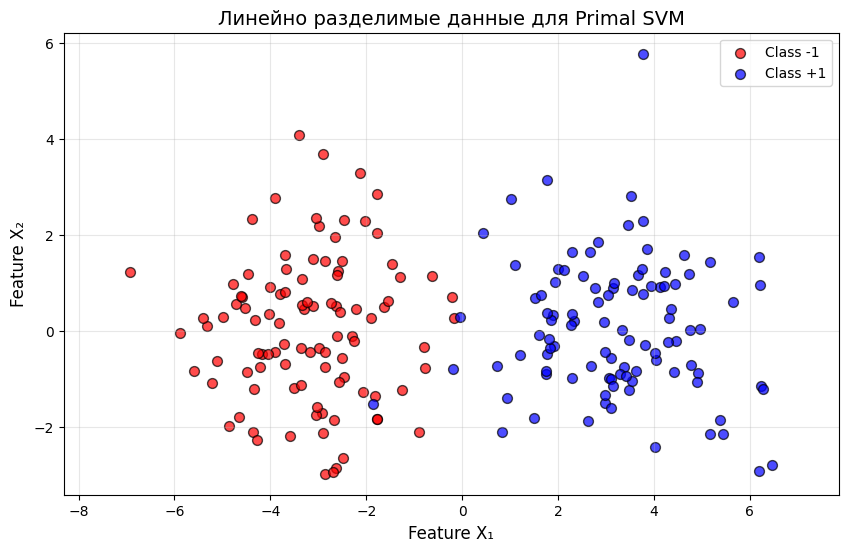

In [3]:
# ============================================
# Визуализация линейно разделимых данных
# ============================================

plt.figure(figsize=(10, 6))
plt.scatter(
    X_linear[y_linear == -1, 0],
    X_linear[y_linear == -1, 1],
    color='red',
    label='Class -1',
    s=50,
    alpha=0.7,
    edgecolors='k'
)
plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    color='blue',
    label='Class +1',
    s=50,
    alpha=0.7,
    edgecolors='k'
)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Линейно разделимые данные для Primal SVM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## 📐 4. Разделяющая линия и Margin — геометрия SVM

### Уравнение гиперплоскости

В двумерном случае разделяющая линия (гиперплоскость) задаётся уравнением:

**w₁·x₁ + w₂·x₂ + b = 0**

где:
- **w = (w₁, w₂)** — вектор весов (нормаль к линии, перпендикулярен ей)
- **b** — смещение (bias)

### Почему w — это нормаль?

Возьмём две точки x₁ и x₂, лежащие на линии:
- w·x₁ + b = 0
- w·x₂ + b = 0

Вычтем: w·(x₁ − x₂) = 0

Вектор (x₁ − x₂) лежит **внутри** линии (соединяет две её точки). Его скалярное произведение с w равно нулю → значит **w перпендикулярен линии**.

### Расстояние от точки до линии

Для точки x₀ расстояние до линии вычисляется по формуле:

**d = |w·x₀ + b| / ||w||**

где ||w|| = √(w₁² + w₂²) — длина (норма) вектора w.

### Границы полосы (Margin)

SVM стремится максимизировать ширину "улицы" между классами. Границы этой улицы задаются двумя параллельными линиями:

- **w·x + b = +1** — ближайшие точки класса +1
- **w·x + b = -1** — ближайшие точки класса -1

### Ширина полосы (Margin)

Расстояние между этими двумя параллельными линиями:

**margin = 2 / ||w||**

**Доказательство (ключевой момент):**

Возьмём точки x⁺ на линии +1 и x⁻ на линии -1, и выберем их так, чтобы вектор (x⁺ − x⁻) был **параллелен нормали w** (кратчайший путь между линиями).

Запишем разность уравнений:
- (w·x⁺ + b) − (w·x⁻ + b) = 1 − (−1) = 2
- w·(x⁺ − x⁻) = 2

Так как x⁺ − x⁻ параллелен w, его можно записать как t · (w/||w||), где t — это искомая длина (расстояние между линиями).

Подставляем:
- w · (t · w/||w||) = 2
- t · ||w|| = 2
- **t = 2 / ||w||** ← это и есть margin!

### Что мы минимизируем?

Наша цель — **максимизировать margin = 2/||w||**.

Дробь тем больше, чем **меньше знаменатель ||w||**. Поэтому максимизация margin эквивалентна **минимизации ||w||²/2** (квадрат для гладкости, 1/2 для удобства дифференцирования).

### Оптимизационная задача (Primal)

**Минимизировать:** (1/2)·||w||²

**При условии:** yᵢ·(w·xᵢ + b) ≥ 1 для всех точек i

где yᵢ = +1 или -1 (метка класса).

Это и есть **примальная задача SVM** — мы будем решать её через градиентный спуск в Главе 2.

## 🎯 5. Визуализация разделяющей линии и Margin

### Теория

После обучения Primal SVM (Глава 2) мы получим w и b. Тогда мы сможем нарисовать:

1. **Разделяющую линию:** w·x + b = 0
2. **Верхнюю границу margin:** w·x + b = +1
3. **Нижнюю границу margin:** w·x + b = -1
4. **Опорные векторы** — точки, которые лежат ровно на границах margin

Здесь мы покажем **как это будет выглядеть**, используя предварительно обученную модель (в Главе 2 мы обучим её сами).

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


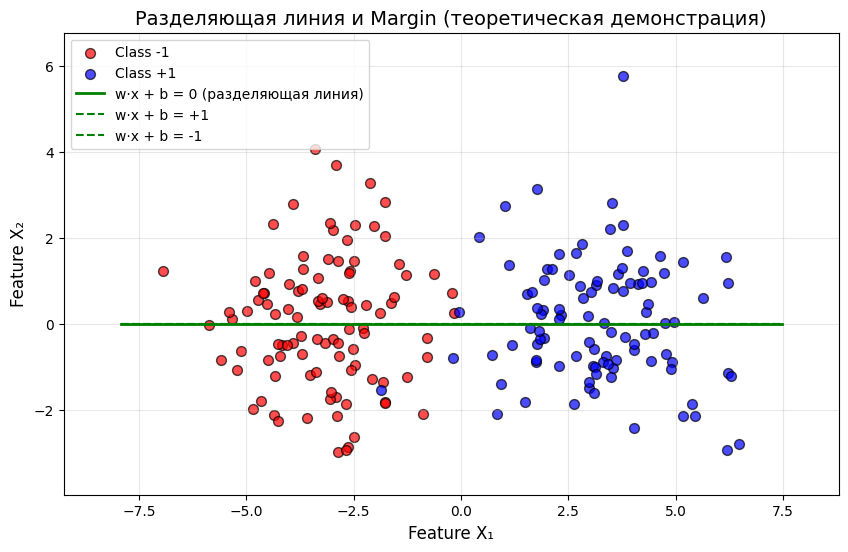

In [6]:
# ============================================
# Демонстрация разделяющей линии и margin
# ============================================

# Для демонстрации мы используем заранее известные w и b
# (в Главе 2 мы научимся их находить через градиентный спуск)

# Примерные значения w и b (полученные после обучения)
w_demo = np.array([0.8, 0.0])
b_demo = 0.0

# Создаём сетку для отрисовки линии
x_min, x_max = X_linear[:, 0].min() - 1, X_linear[:, 0].max() + 1
y_min, y_max = X_linear[:, 1].min() - 1, X_linear[:, 1].max() + 1

# Линия уровня для w·x + b = 0
xx = np.linspace(x_min, x_max, 100)
yy_sep = -(w_demo[0] * xx + b_demo) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)

# Линии уровня для w·x + b = ±1 (границы margin)
yy_plus = -(w_demo[0] * xx + b_demo - 1) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)
yy_minus = -(w_demo[0] * xx + b_demo + 1) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)

# Рисуем
plt.figure(figsize=(10, 6))

# Точки
plt.scatter(
    X_linear[y_linear == -1, 0],
    X_linear[y_linear == -1, 1],
    color='red', label='Class -1', s=50, alpha=0.7, edgecolors='k'
)
plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    color='blue', label='Class +1', s=50, alpha=0.7, edgecolors='k'
)

# Разделяющая линия
plt.plot(xx, yy_sep, 'g-', linewidth=2, label='w·x + b = 0 (разделяющая линия)')

# Границы margin
plt.plot(xx, yy_plus, 'g--', linewidth=1.5, label='w·x + b = +1')
plt.plot(xx, yy_minus, 'g--', linewidth=1.5, label='w·x + b = -1')

# Заливка полосы (margin)
plt.fill_between(xx, yy_minus, yy_plus, color='green', alpha=0.1)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Разделяющая линия и Margin (теоретическая демонстрация)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

## 🧠 6. Генерация нелинейных данных для тестирования ядер

### Теория

Для тестирования ядер (RBF, Polynomial) нам нужны данные, которые **нельзя разделить прямой линией**. Мы сгенерируем три классических паттерна:

1. **Концентрические окружности (Circles)** — один класс внутри круга, другой — снаружи. Прямая линия не справится, нужна круговая граница (RBF-ядро).
2. **Два полумесяца (Moons)** — два изогнутых кластера. Классический тест для нелинейных классификаторов.
3. **XOR-паттерн** — четыре кластера по углам, классы расположены по диагонали.

Все эти паттерны встроены в sklearn и генерируются одной строкой.

In [7]:
# ============================================
# 2. Концентрические окружности (для RBF-ядра)
# ============================================

X_circles, y_circles = make_circles(
    n_samples=n_samples,
    factor=0.5,
    noise=0.05,
    random_state=42
)
y_circles = np.where(y_circles == 0, -1, 1)

# ============================================
# 3. Два полумесяца (Moons)
# ============================================

X_moons, y_moons = make_moons(
    n_samples=n_samples,
    noise=0.05,
    random_state=42
)
y_moons = np.where(y_moons == 0, -1, 1)

# ============================================
# 4. XOR-паттерн (вручную)
# ============================================

np.random.seed(42)
n_xor = n_samples // 4

# Четыре кластера по углам
X_xor_1 = np.random.randn(n_xor, 2) + np.array([-2, -2])
X_xor_2 = np.random.randn(n_xor, 2) + np.array([-2, 2])
X_xor_3 = np.random.randn(n_xor, 2) + np.array([2, -2])
X_xor_4 = np.random.randn(n_xor, 2) + np.array([2, 2])

X_xor = np.vstack([X_xor_1, X_xor_2, X_xor_3, X_xor_4])

# Метки по диагонали: класс -1 для левого-верхнего и правого-нижнего
y_xor = np.hstack([
    np.ones(n_xor),      # левый-нижний → +1
    -np.ones(n_xor),     # левый-верхний → -1
    -np.ones(n_xor),     # правый-нижний → -1
    np.ones(n_xor)       # правый-верхний → +1
])

print(f"X_circles shape: {X_circles.shape}")
print(f"X_moons shape: {X_moons.shape}")
print(f"X_xor shape: {X_xor.shape}")

X_circles shape: (200, 2)
X_moons shape: (200, 2)
X_xor shape: (200, 2)


## 📊 7. Визуализация нелинейных данных

Здесь мы визуализируем все три нелинейных паттерна, чтобы увидеть, почему прямая линия не сможет их разделить.

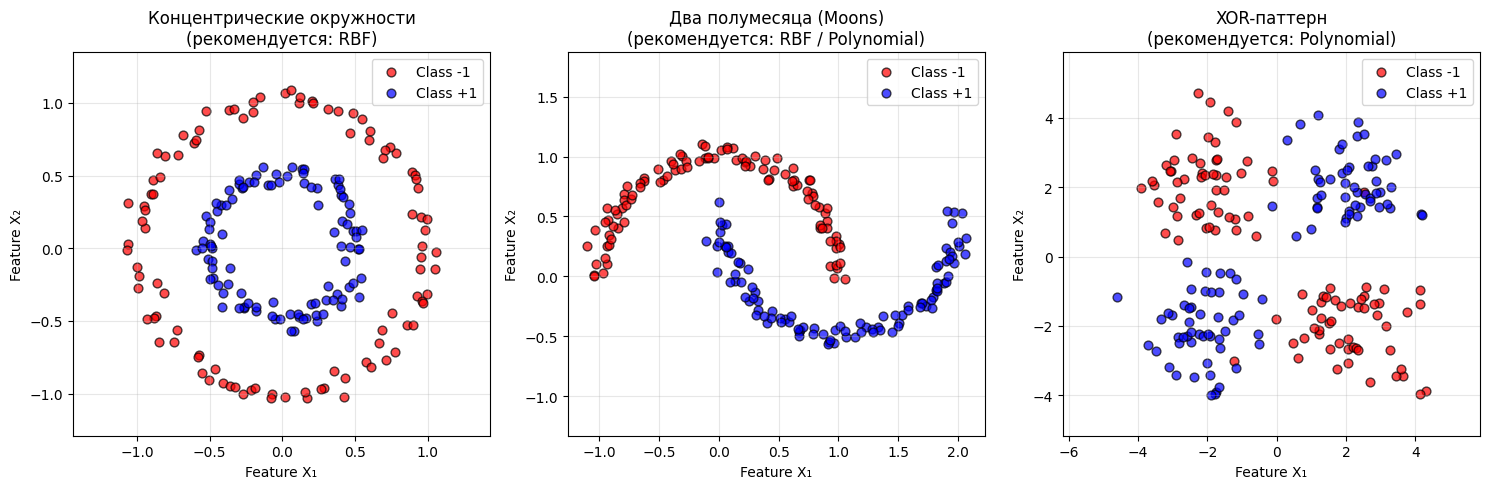

In [8]:
# ============================================
# Визуализация всех трёх нелинейных паттернов
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (X_circles, y_circles, 'Концентрические окружности', 'RBF'),
    (X_moons, y_moons, 'Два полумесяца (Moons)', 'RBF / Polynomial'),
    (X_xor, y_xor, 'XOR-паттерн', 'Polynomial')
]

for ax, (X, y, title, kernel) in zip(axes, datasets):
    ax.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', s=40, alpha=0.7, edgecolors='k')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class +1', s=40, alpha=0.7, edgecolors='k')
    ax.set_title(f'{title}\n(рекомендуется: {kernel})', fontsize=12)
    ax.set_xlabel('Feature X₁')
    ax.set_ylabel('Feature X₂')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.show()

## 📝 8. Итоговые выводы

### Что мы сделали в этой главе

1. **Разобрали теорию многомерного нормального распределения** — как ковариационная матрица управляет формой облака точек (круг, овал, наклон).

2. **Сгенерировали линейно разделимые данные** — два облака с разными центрами, которые можно разделить прямой линией (для Primal SVM).

3. **Разобрали геометрию SVM**:
   - Уравнение гиперплоскости: w·x + b = 0
   - Расстояние от точки до линии: |w·x + b| / ||w||
   - Границы margin: w·x + b = ±1
   - Ширина margin: 2 / ||w||

4. **Визуализировали разделяющую линию и margin** — показали, как будет выглядеть результат обучения.

5. **Сгенерировали нелинейные данные** для тестирования ядер:
   - Концентрические окружности → RBF-ядро
   - Два полумесяца → RBF / Polynomial
   - XOR-паттерн → Polynomial

### Что дальше

В **Главе 2** мы реализуем **Primal SVM** (градиентный спуск по w и b) и нарисуем **реальную** разделяющую линию, полученную в результате обучения, а не теоретическую демонстрацию.

В **Главе 3** мы перейдём к **Dual SVM** с ядрами и научимся разделять нелинейные данные.

### Ключевые формулы для запоминания

| Что | Формула |
|---|---|
| Гиперплоскость | w·x + b = 0 |
| Расстояние до точки | d = |w·x₀ + b| / ||w|| |
| Границы margin | w·x + b = ±1 |
| Ширина margin | margin = 2 / ||w|| |
| Задача оптимизации | min ½||w||², при yᵢ(w·xᵢ+b) ≥ 1 |

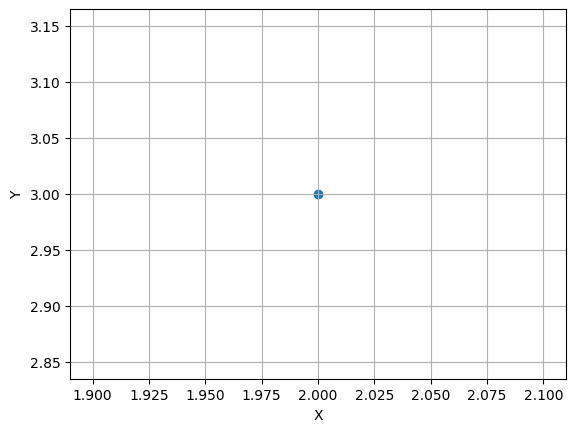

In [1]:
import numpy as np
import matplotlib.pyplot as plt

mean_minus1 = np.array([2.0, 3.0])

plt.scatter(mean_minus1[0], mean_minus1[1])
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()